# Variační Bayesovský Gaussovský Model Směsi (VBGMM)

## Co je VBGMM?

Variační Bayesovský Gaussovský Model Směsi (Variational Bayesian Gaussian Mixture Model - VBGMM) je flexibilní shlukovací algoritmus, který rozšiřuje standardní Gaussovské modely směsi (GMM) pomocí Bayesovského přístupu. Ve scikit-learn je tento algoritmus implementován jako `BayesianGaussianMixture`.

### Klíčové vlastnosti VBGMM:

- **Automatické určení počtu shluků**: Na rozdíl od standardního GMM, VBGMM může automaticky určit efektivní počet komponent (shluků) na základě dat
- **Bayesovský přístup**: Používá variační bayesovskou inferenci namísto maximalizace věrohodnosti
- **Prevence přefitování**: Je méně náchylný k přefitování díky bayesovské regularizaci
- **Variační apriorní koncentrace vah**: Parametr, který určuje, jak silně algoritmus preferuje méně komponent

### Kdy použít VBGMM:

- Když neznáte předem přesný počet shluků v datech
- Pro data, která můžete smysluplně modelovat jako směs Gaussovských rozdělení
- Když chcete robustnější shlukování než standardní GMM
- Pro generativní modelování dat s neznámým počtem zdrojů

In [1]:
# Import potřebných knihoven
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.mixture import BayesianGaussianMixture, GaussianMixture
from sklearn.datasets import make_blobs, load_iris, fetch_olivetti_faces
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
import time

# Nastavení vizuálního stylu
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
np.random.seed(42)

## 1. Základní použití VBGMM

Nejprve si ukážeme základní použití algoritmu na syntetických datech.

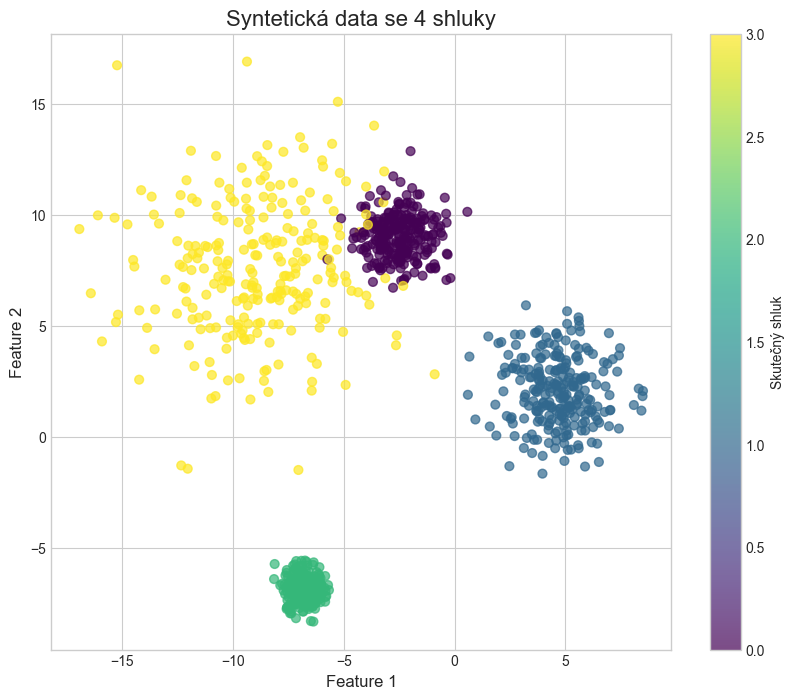

In [2]:
# Vytvoření syntetických dat se známým počtem shluků
n_samples = 1000
true_centers = 4
X, y_true = make_blobs(n_samples=n_samples, centers=true_centers, 
                      cluster_std=[1.0, 1.5, 0.5, 3.0], random_state=42)

# Vizualizace původních dat
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.7, s=40)
plt.title('Syntetická data se 4 shluky', fontsize=16)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.colorbar(label='Skutečný shluk')
plt.grid(True)
plt.show()

In [3]:
# Aplikace VBGMM s více komponentami, než je skutečný počet shluků
vbgmm = BayesianGaussianMixture(
    n_components=10,              # Počáteční počet komponent (větší než skutečný počet)
    weight_concentration_prior=0.1,  # Důležitý parametr regulace počtu komponent
    random_state=42,
    max_iter=200,
    tol=1e-3
)

# Měření času výpočtu
start_time = time.time()
vbgmm.fit(X)
fit_time = time.time() - start_time

# Získání predikcí shluků
labels = vbgmm.predict(X)

# Počet efektivních komponent (shluků)
n_effective_components = np.sum(vbgmm.weights_ > 0.01)

print(f"Doba výpočtu: {fit_time:.3f} sekund")
print(f"Počáteční počet komponent: 10")
print(f"Skutečný počet shluků v datech: {true_centers}")
print(f"Efektivní počet detekovaných komponent (weight > 1%): {n_effective_components}")
print(f"\nVáhy komponent:")
for i, w in enumerate(vbgmm.weights_):
    print(f"Komponenta {i+1}: {w:.4f}")

Doba výpočtu: 1.715 sekund
Počáteční počet komponent: 10
Skutečný počet shluků v datech: 4
Efektivní počet detekovaných komponent (weight > 1%): 4

Váhy komponent:
Komponenta 1: 0.2548
Komponenta 2: 0.2504
Komponenta 3: 0.2504
Komponenta 4: 0.2443
Komponenta 5: 0.0001
Komponenta 6: 0.0000
Komponenta 7: 0.0000
Komponenta 8: 0.0000
Komponenta 9: 0.0000
Komponenta 10: 0.0000


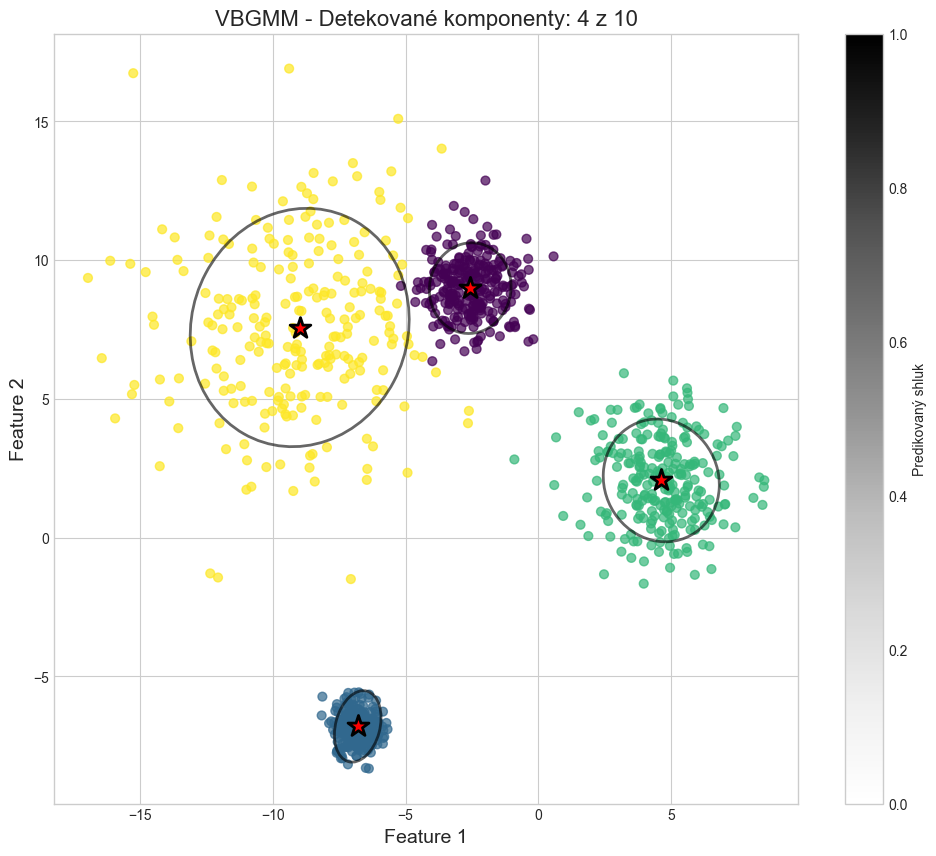

In [4]:
# Vizualizace výsledků shlukování
plt.figure(figsize=(12, 10))

# Vykreslení bodů s barvami podle predikcí
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7, s=40)

# Vykreslení center komponent s velikostí odpovídající váhám
for i, (mean, covar, weight) in enumerate(zip(vbgmm.means_, vbgmm.covariances_, vbgmm.weights_)):
    if weight > 0.01:  # Zobrazení pouze významných komponent
        v, w = np.linalg.eigh(covar)
        v = 2. * np.sqrt(2.) * np.sqrt(v)
        u = w[0] / np.linalg.norm(w[0])
        angle = np.arctan2(u[1], u[0])
        angle = 180. * angle / np.pi
        
        # Vykreslení elipsy pro každou komponentu
        ell = plt.matplotlib.patches.Ellipse(
            mean, v[0], v[1], angle=180. + angle, 
            edgecolor='black', lw=2,
            facecolor='none', alpha=0.6
        )
        ell.set_clip_box(plt.gca().bbox)
        plt.gca().add_artist(ell)
        
        # Zobrazení středů s velikostí podle váhy
        plt.scatter(
            mean[0], mean[1], 
            s=1000 * weight, 
            c='red', marker='*', 
            edgecolor='black', linewidth=2,
            zorder=10
        )
        # Přidat číslo komponenty
        plt.annotate(f"{i+1}", (mean[0], mean[1]), fontsize=12, ha='center', va='center')

plt.title(f'VBGMM - Detekované komponenty: {n_effective_components} z 10', fontsize=16)
plt.xlabel('Feature 1', fontsize=14)
plt.ylabel('Feature 2', fontsize=14)
plt.grid(True)
plt.colorbar(label='Predikovaný shluk')
plt.show()

Silhouette skóre: 0.678
Adjusted Rand Index: 0.966


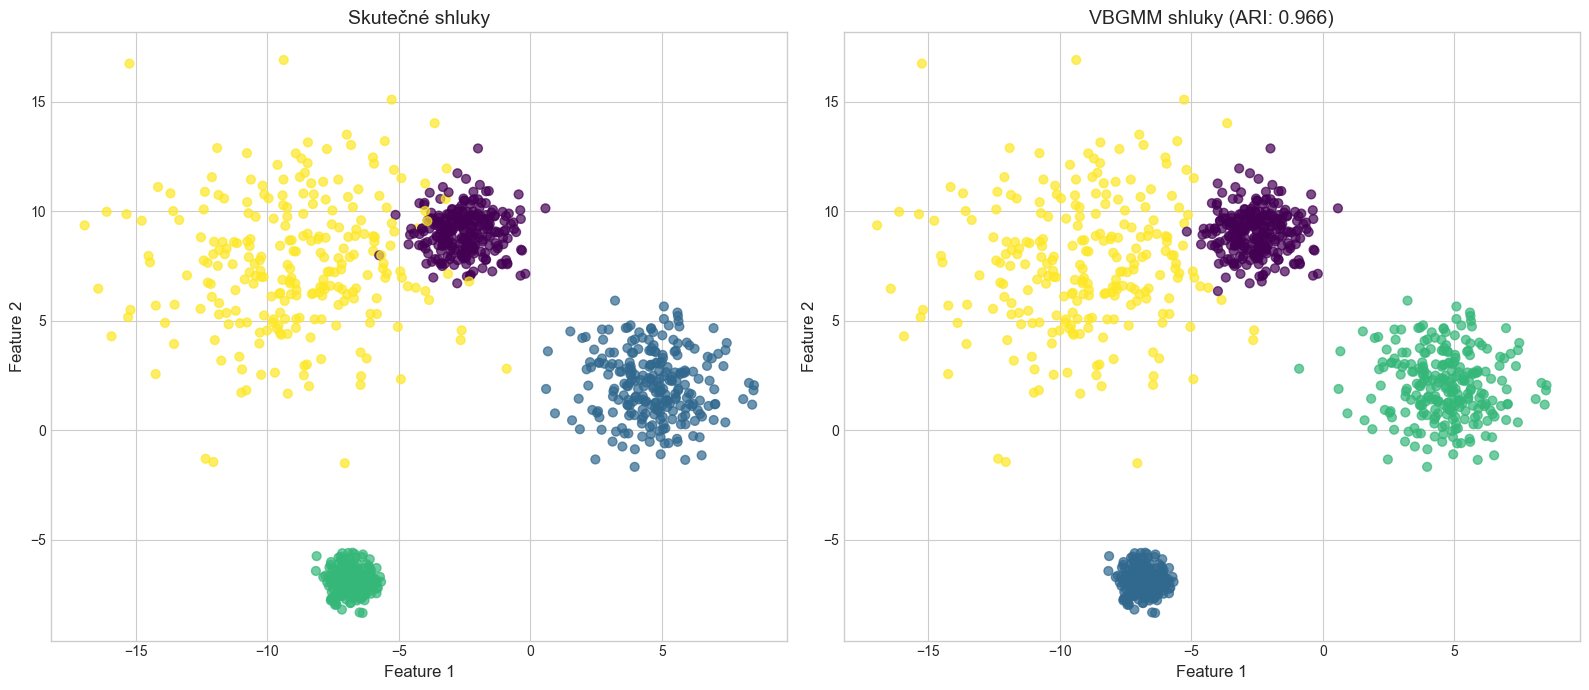

In [5]:
# Výpočet metrik kvality shlukování
unique_labels = np.unique(labels)
if len(unique_labels) > 1:  # Silhouette skóre lze počítat jen pro více než jeden shluk
    silhouette = silhouette_score(X, labels)
    print(f"Silhouette skóre: {silhouette:.3f}")

# Adjusted Rand Index (porovnání se skutečnými třídami)
ari = adjusted_rand_score(y_true, labels)
print(f"Adjusted Rand Index: {ari:.3f}")

# Porovnání predikcí s pravými shluky
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Skutečné shluky
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.7, s=40)
axes[0].set_title('Skutečné shluky', fontsize=14)
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].grid(True)

# VBGMM shluky
axes[1].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7, s=40)
axes[1].set_title(f'VBGMM shluky (ARI: {ari:.3f})', fontsize=14)
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 2. Vliv parametru weight_concentration_prior

Parametr `weight_concentration_prior` je klíčový pro určení, kolik komponent bude efektivně využito. Nižší hodnoty vedou k menšímu počtu komponent.

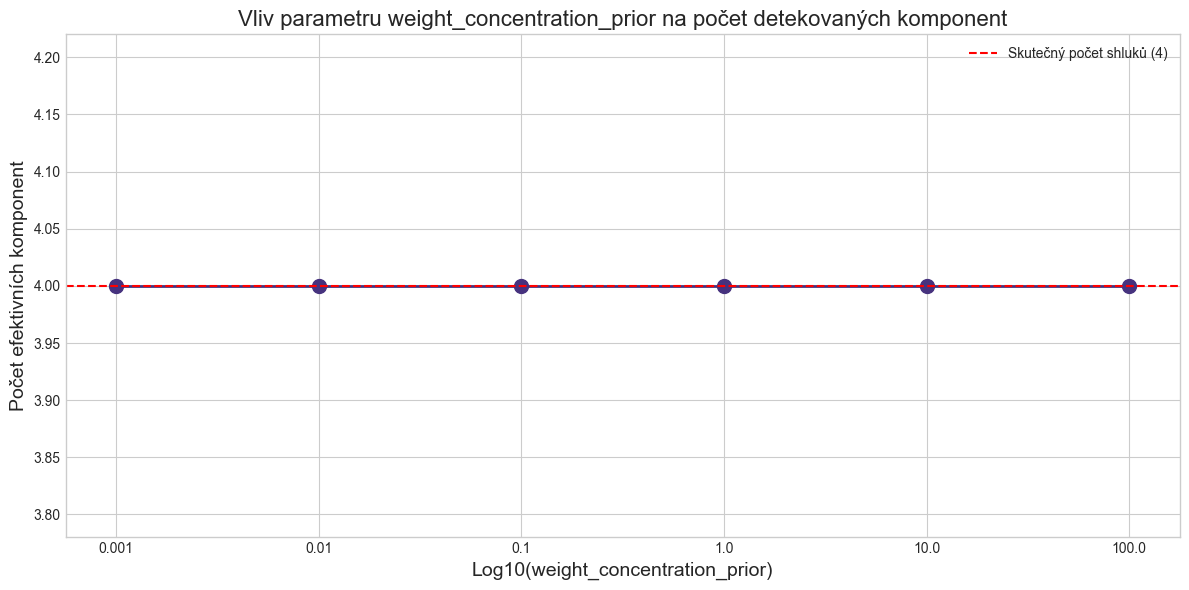

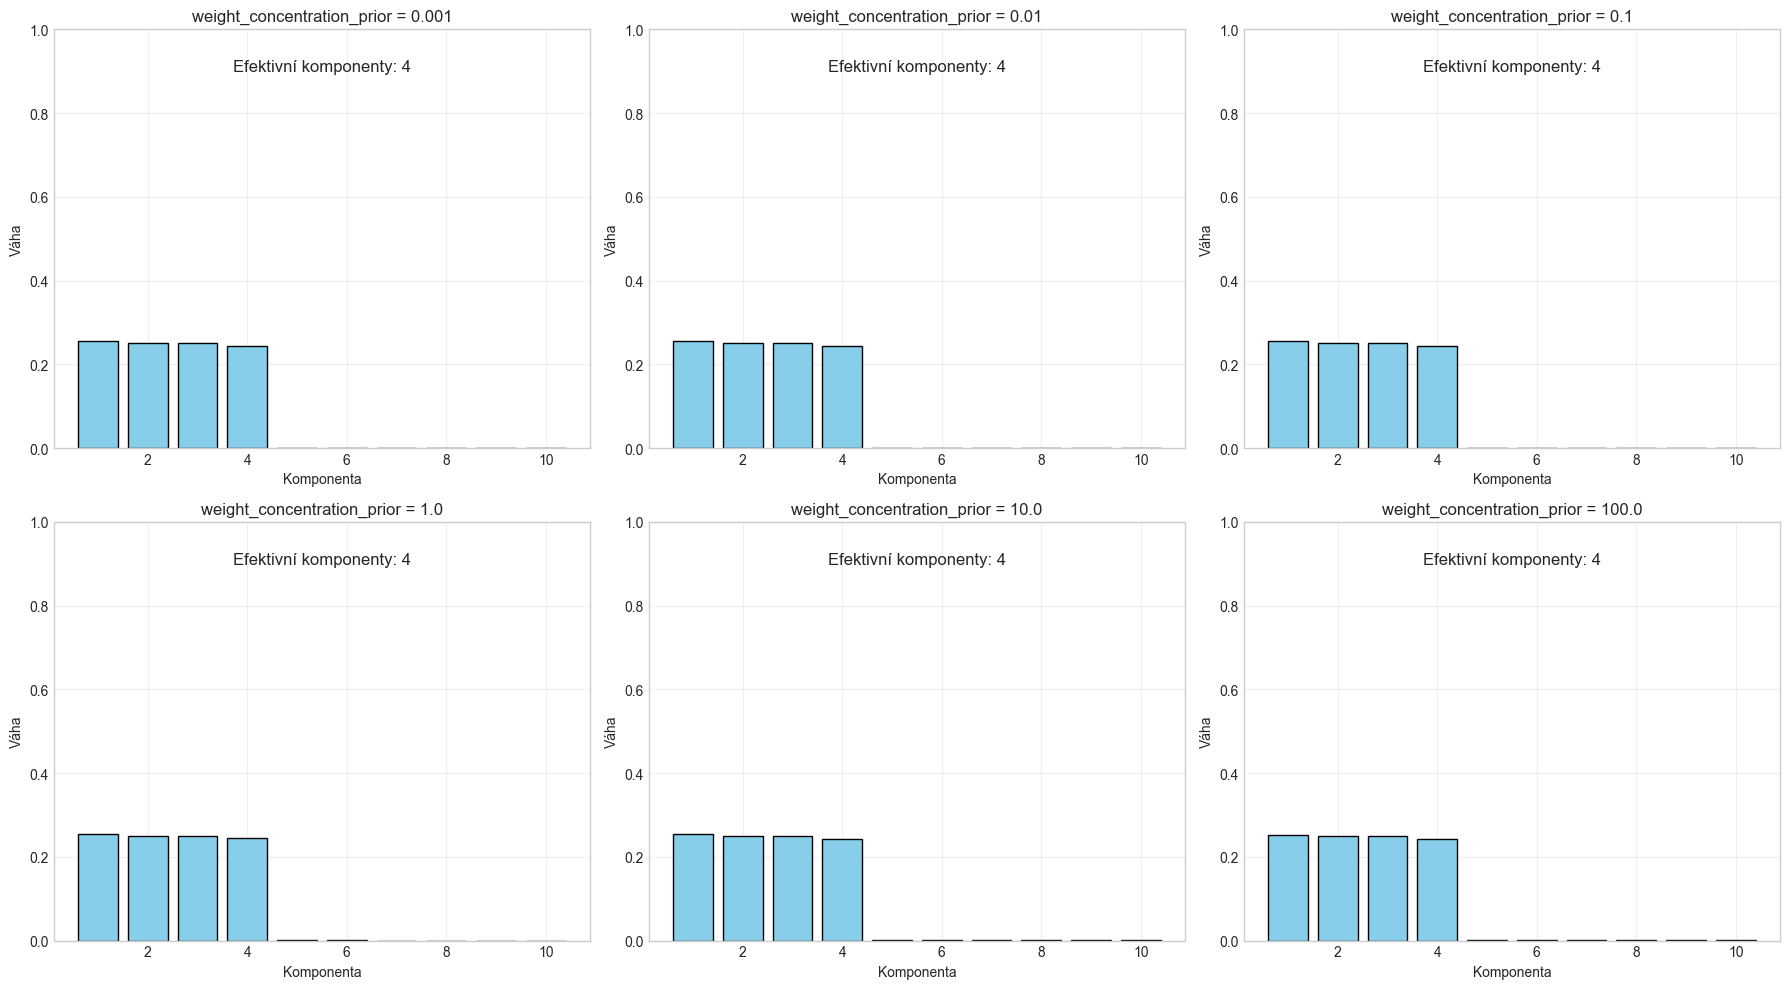

In [6]:
# Porovnání různých hodnot weight_concentration_prior
priors = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
models = []
effective_components = []

for prior in priors:
    vbgmm = BayesianGaussianMixture(
        n_components=10,
        weight_concentration_prior=prior,
        random_state=42,
        max_iter=200
    )
    vbgmm.fit(X)
    models.append(vbgmm)
    
    # Počet efektivních komponent
    n_eff = np.sum(vbgmm.weights_ > 0.01)
    effective_components.append(n_eff)

# Zobrazení výsledků
plt.figure(figsize=(12, 6))
plt.plot(np.log10(priors), effective_components, 'o-', linewidth=2, markersize=10)
plt.axhline(y=true_centers, color='r', linestyle='--', label=f'Skutečný počet shluků ({true_centers})')
plt.xlabel('Log10(weight_concentration_prior)', fontsize=14)
plt.ylabel('Počet efektivních komponent', fontsize=14)
plt.title('Vliv parametru weight_concentration_prior na počet detekovaných komponent', fontsize=16)
plt.grid(True)
plt.xticks(np.log10(priors), [f"{p}" for p in priors])
plt.legend()
plt.tight_layout()
plt.show()

# Tabulka s výsledky
results = pd.DataFrame({
    'weight_concentration_prior': priors,
    'Počet efektivních komponent': effective_components,
    'Váhy': [m.weights_ for m in models]
})

# Zobrazení vah pro každou hodnotu prior
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (prior, model) in enumerate(zip(priors, models)):
    weights = model.weights_
    axes[i].bar(range(1, 11), weights, color='skyblue', edgecolor='black')
    axes[i].set_title(f'weight_concentration_prior = {prior}', fontsize=12)
    axes[i].set_xlabel('Komponenta', fontsize=10)
    axes[i].set_ylabel('Váha', fontsize=10)
    axes[i].set_ylim(0, 1)
    axes[i].grid(True, alpha=0.3)
    
    # Zobrazení počtu efektivních komponent
    axes[i].text(0.5, 0.9, f"Efektivní komponenty: {effective_components[i]}", 
                transform=axes[i].transAxes, ha='center', fontsize=12)

plt.tight_layout()
plt.show()

## 3. Porovnání VBGMM s klasickým GMM

Porovnejme výkon a výsledky VBGMM s klasickým Gaussian Mixture Model.

In [7]:
# # Vytvoření dat s překrývajícími se shluky
# X_overlap, y_overlap = make_blobs(n_samples=1000, centers=3, 
#                                 cluster_std=[1.0, 1.5, 0.5], random_state=12)

# # Přidání šumu a posunutí pro vytvoření překryvu
# X_overlap[:300, 0] += 4
# X_overlap[300:600, 1] -= 3

# # Aplikace standardního GMM
# gmm = GaussianMixture(n_components=5, random_state=42)
# start_time = time.time()
# gmm.fit(X_overlap)
# gmm_time = time.time() - start_time
# gmm_labels = gmm.predict(X_overlap)

# # Aplikace VBGMM
# vbgmm = BayesianGaussianMixture(
#     n_components=5, 
#     weight_concentration_prior=0.1, 
#     random_state=42
# )
# start_time = time.time()
# vbgmm.fit(X_overlap)
# vbgmm_time = time.time() - start_time
# vbgmm_labels = vbgmm.predict(X_overlap)

# # Počet efektivních komponent
# vbgmm_n_eff = np.sum(vbgmm.weights_ > 0.01)

# # Metriky kvality
# gmm_silhouette = silhouette_score(X_overlap, gmm_labels) if len(np.unique(gmm_labels)) > 1 else 0
# vbgmm_silhouette = silhouette_score(X_overlap, vbgmm_labels) if len(np.unique(vbgmm_labels)) > 1 else 0

# # BIC a AIC (nižší je lepší)
# gmm_bic = gmm.bic(X_overlap)
# gmm_aic = gmm.aic(X_overlap)
# # VBGMM používá jiné metriky
# vbgmm_lower_bound = vbgmm.lower_bound_

# # Výsledky
# print(f"GMM (standardní):\n"
#       f"  - Počet komponent: 5 (pevně daný)\n"
#       f"  - Doba výpočtu: {gmm_time:.3f} s\n"
#       f"  - Silhouette skóre: {gmm_silhouette:.3f}\n"
#       f"  - BIC: {gmm_bic:.1f}\n"
#       f"  - AIC: {gmm_aic:.1f}\n")

# print(f"VBGMM (bayesovský):\n"
#       f"  - Počáteční počet komponent: 5\n"
#       f"  - Efektivní počet komponent: {vbgmm_n_eff}\n"
#       f"  - Doba výpočtu: {vbgmm_time:.3f} s\n"
#       f"  - Silhouette skóre: {vbgmm_silhouette:.3f}\n"
#       f"  - Lower Bound: {vbgmm_lower_bound:.1f}\n")

# # Vizualizace výsledků
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# # Původní data
# axes[0].scatter(X_overlap[:, 0], X_overlap[:, 1], c=y_overlap, cmap='viridis', alpha=0.7, s=40)
# axes[0].set_title('Původní data s překryvem', fontsize=14)
# axes[0].set_xlabel('Feature 1', fontsize=12)
# axes[0].set_ylabel('Feature 2', fontsize=12)
# axes[0].grid(True)

# # GMM
# axes[1].scatter(X_overlap[:, 0], X_overlap[:, 1], c=gmm_labels, cmap='viridis', alpha=0.7, s=40)
# for i, (mean, covar) in enumerate(zip(gmm.means_, gmm.covariances_)):
#     v, w = np.linalg.eigh(covar)
#     v = 2. * np.sqrt(2.) * np.sqrt(v)
#     u = w[0] / np.linalg.norm(w[0])
#     angle = np.arctan2(u[1], u[0])
#     angle = 180. * angle / np.pi
#     ell = plt.matplotlib.patches.Ellipse(
#         mean, v[0], v[1], angle=180. + angle, 
#         edgecolor='black', lw=1.5, facecolor='none', alpha=0.6
#     )
#     ell.set_clip_box(axes[1].bbox)
#     axes[1].add_artist(ell)
# axes[1].set_title(f'GMM (k=5)\nSilhouette: {gmm_silhouette:.3f}', fontsize=14)
# axes[1].set_xlabel('Feature 1', fontsize=12)
# axes[1].set_ylabel('Feature 2', fontsize=12)
# axes[1].grid(True)

# # VBGMM
# axes[2].scatter(X_overlap[:, 0], X_overlap[:, 1], c=vbgmm_labels, cmap='viridis', alpha=0.7, s=40)
# for i, (mean, covar, weight) in enumerate(zip(vbgmm.means_, vbgmm.covariances_, vbgmm.weights_)):
#     if weight > 0.01:  # Zobrazení pouze významných komponent
#         v, w = np.linalg.eigh(covar)
#         v = 2. * np.sqrt(2.) * np.sqrt(v)
#         u = w[0] / np.linalg.norm(w[0])
#         angle = np.arctan2(u[1], u[0])
#         angle = 180. * angle / np.pi
#         ell = plt.matplotlib.patches.Ellipse(
#             mean, v[0], v[1], angle=180. + angle, 
#             edgecolor='black', lw=1.5, facecolor='none', alpha=0.6
#         )
#         ell.set_clip_box(axes[2].bbox)
#         axes[2].add_artist(ell)
# axes[2].set_title(f'VBGMM (efektivní k={vbgmm_n_eff})\nSilhouette: {vbgmm_silhouette:.3f}', fontsize=14)
# axes[2].set_xlabel('Feature 1', fontsize=12)
# axes[2].set_ylabel('Feature 2', fontsize=12)
# axes[2].grid(True)

# plt.tight_layout()
# plt.show()

# # Zobrazení vah komponent
# plt.figure(figsize=(12, 6))
# width = 0.35
# x = np.arange(5)

# plt.bar(x - width/2, gmm.weights_, width, label='GMM', alpha=0.7, edgecolor='black')
# plt.bar(x + width/2, vbgmm.weights_, width, label='VBGMM', alpha=0.7, edgecolor='black')

# plt.xlabel('Komponenta', fontsize=14)
# plt.ylabel('Váha', fontsize=14)
# plt.title('Porovnání vah komponent: GMM vs VBGMM', fontsize=16)
# plt.xticks(x, [f'{i+1}' for i in range(5)])
# plt.legend(fontsize=12)
# plt.grid(True, alpha=0.3)
# plt.show()

```
ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
```

GMM (standardní):
  - Počet komponent: 5 (pevně daný)
  - Doba výpočtu: 0.058 s
  - Silhouette skóre: 0.352
  - BIC: 9529.9
  - AIC: 9387.6

VBGMM (bayesovský):
  - Počáteční počet komponent: 5
  - Efektivní počet komponent: 5
  - Doba výpočtu: 0.272 s
  - Silhouette skóre: 0.374
  - Lower Bound: -3020.5



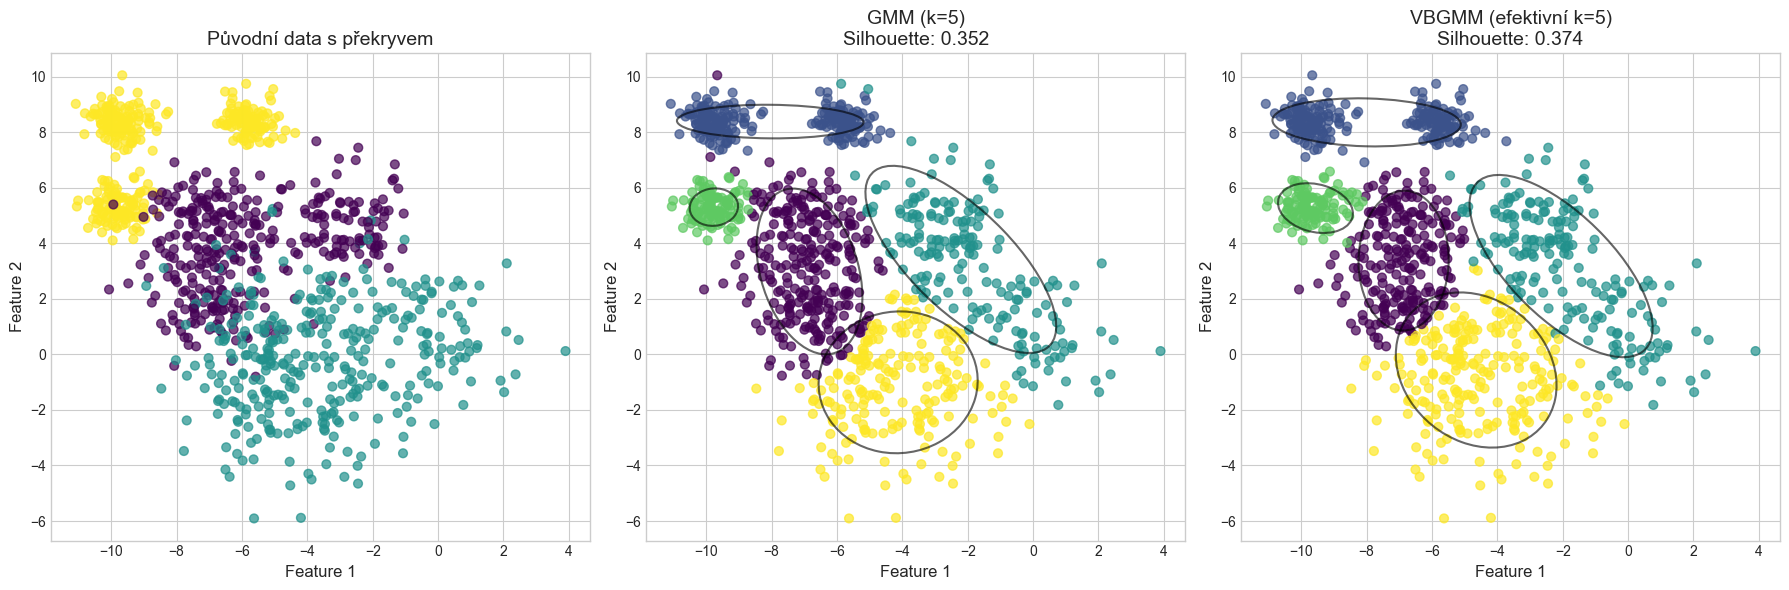

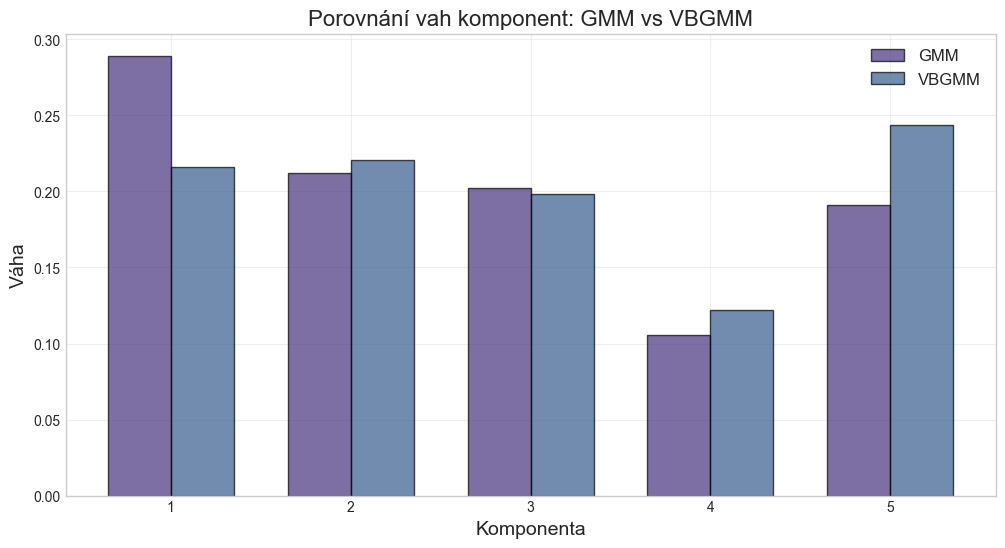

In [8]:
from sklearn.mixture import GaussianMixture
from sklearn.mixture import BayesianGaussianMixture
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings

# Vytvoření dat s překrývajícími se shluky
X_overlap, y_overlap = make_blobs(n_samples=1000, centers=3, 
                                cluster_std=[1.0, 1.5, 0.5], random_state=12)

# Přidání šumu a posunutí pro vytvoření překryvu
X_overlap[:300, 0] += 4
X_overlap[300:600, 1] -= 3

# Aplikace standardního GMM
gmm = GaussianMixture(n_components=5, random_state=42, max_iter=500, tol=1e-4)
start_time = time.time()
gmm.fit(X_overlap)
gmm_time = time.time() - start_time
gmm_labels = gmm.predict(X_overlap)

# Aplikace VBGMM
vbgmm = BayesianGaussianMixture(
    n_components=5, 
    weight_concentration_prior=0.1, 
    random_state=42, 
    max_iter=500, 
    tol=1e-4
)
start_time = time.time()
vbgmm.fit(X_overlap)
vbgmm_time = time.time() - start_time
vbgmm_labels = vbgmm.predict(X_overlap)

# Počet efektivních komponent
vbgmm_n_eff = np.sum(vbgmm.weights_ > 0.01)

# Metriky kvality
gmm_silhouette = silhouette_score(X_overlap, gmm_labels) if len(np.unique(gmm_labels)) > 1 else 0
vbgmm_silhouette = silhouette_score(X_overlap, vbgmm_labels) if len(np.unique(vbgmm_labels)) > 1 else 0

# BIC a AIC (nižší je lepší)
gmm_bic = gmm.bic(X_overlap)
gmm_aic = gmm.aic(X_overlap)
# VBGMM používá jiné metriky
vbgmm_lower_bound = vbgmm.lower_bound_

# Výsledky
print(f"GMM (standardní):\n"
      f"  - Počet komponent: 5 (pevně daný)\n"
      f"  - Doba výpočtu: {gmm_time:.3f} s\n"
      f"  - Silhouette skóre: {gmm_silhouette:.3f}\n"
      f"  - BIC: {gmm_bic:.1f}\n"
      f"  - AIC: {gmm_aic:.1f}\n")

print(f"VBGMM (bayesovský):\n"
      f"  - Počáteční počet komponent: 5\n"
      f"  - Efektivní počet komponent: {vbgmm_n_eff}\n"
      f"  - Doba výpočtu: {vbgmm_time:.3f} s\n"
      f"  - Silhouette skóre: {vbgmm_silhouette:.3f}\n"
      f"  - Lower Bound: {vbgmm_lower_bound:.1f}\n")

# Vizualizace výsledků
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Původní data
axes[0].scatter(X_overlap[:, 0], X_overlap[:, 1], c=y_overlap, cmap='viridis', alpha=0.7, s=40)
axes[0].set_title('Původní data s překryvem', fontsize=14)
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].grid(True)

# GMM
axes[1].scatter(X_overlap[:, 0], X_overlap[:, 1], c=gmm_labels, cmap='viridis', alpha=0.7, s=40)
for i, (mean, covar) in enumerate(zip(gmm.means_, gmm.covariances_)):
    v, w = np.linalg.eigh(covar)
    v = 2. * np.sqrt(2.) * np.sqrt(v)
    u = w[0] / np.linalg.norm(w[0])
    angle = np.arctan2(u[1], u[0])
    angle = 180. * angle / np.pi
    ell = plt.matplotlib.patches.Ellipse(
        mean, v[0], v[1], angle=180. + angle, 
        edgecolor='black', lw=1.5, facecolor='none', alpha=0.6
    )
    ell.set_clip_box(axes[1].bbox)
    axes[1].add_artist(ell)
axes[1].set_title(f'GMM (k=5)\nSilhouette: {gmm_silhouette:.3f}', fontsize=14)
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].grid(True)

# VBGMM
axes[2].scatter(X_overlap[:, 0], X_overlap[:, 1], c=vbgmm_labels, cmap='viridis', alpha=0.7, s=40)
for i, (mean, covar, weight) in enumerate(zip(vbgmm.means_, vbgmm.covariances_, vbgmm.weights_)):
    if weight > 0.01:  # Zobrazení pouze významných komponent
        v, w = np.linalg.eigh(covar)
        v = 2. * np.sqrt(2.) * np.sqrt(v)
        u = w[0] / np.linalg.norm(w[0])
        angle = np.arctan2(u[1], u[0])
        angle = 180. * angle / np.pi
        ell = plt.matplotlib.patches.Ellipse(
            mean, v[0], v[1], angle=180. + angle, 
            edgecolor='black', lw=1.5, facecolor='none', alpha=0.6
        )
        ell.set_clip_box(axes[2].bbox)
        axes[2].add_artist(ell)
axes[2].set_title(f'VBGMM (efektivní k={vbgmm_n_eff})\nSilhouette: {vbgmm_silhouette:.3f}', fontsize=14)
axes[2].set_xlabel('Feature 1', fontsize=12)
axes[2].set_ylabel('Feature 2', fontsize=12)
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Zobrazení vah komponent
plt.figure(figsize=(12, 6))
width = 0.35
x = np.arange(5)

plt.bar(x - width/2, gmm.weights_, width, label='GMM', alpha=0.7, edgecolor='black')
plt.bar(x + width/2, vbgmm.weights_, width, label='VBGMM', alpha=0.7, edgecolor='black')

plt.xlabel('Komponenta', fontsize=14)
plt.ylabel('Váha', fontsize=14)
plt.title('Porovnání vah komponent: GMM vs VBGMM', fontsize=16)
plt.xticks(x, [f'{i+1}' for i in range(5)])
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## 4. Vliv různých typů kovariančních matic

VBGMM podporuje různé typy kovariančních matic, které ovlivňují tvar a orientaci shluků.

In [9]:
# # Vytvoření dat se složitějšími shluky
# np.random.seed(42)
# X_complex = np.vstack([
#     np.random.multivariate_normal([0, 0], [[1, 0], [0, 1]], 200),  # Kulatý shluk
#     np.random.multivariate_normal([6, 0], [[3, 1], [1, 1]], 300),  # Eliptický shluk
#     np.random.multivariate_normal([0, 6], [[1, 0], [0, 3]], 250)   # Eliptický shluk ve směru y
# ])
# y_complex = np.hstack([np.zeros(200), np.ones(300), 2*np.ones(250)])

# # Typy kovariančních matic
# cov_types = ['full', 'tied', 'diag', 'spherical']
# models = []
# labels = []

# for cov_type in cov_types:
#     vbgmm = BayesianGaussianMixture(
#         n_components=5,
#         covariance_type=cov_type,
#         weight_concentration_prior=0.1,
#         random_state=42,
#         max_iter=200
#     )
#     vbgmm.fit(X_complex)
#     models.append(vbgmm)
#     labels.append(vbgmm.predict(X_complex))

# # Vizualizace výsledků
# fig, axes = plt.subplots(2, 3, figsize=(18, 12))
# axes = axes.flatten()

# # Původní data
# axes[0].scatter(X_complex[:, 0], X_complex[:, 1], c=y_complex, cmap='viridis', alpha=0.7, s=40)
# axes[0].set_title('Původní data', fontsize=14)
# axes[0].set_xlabel('Feature 1', fontsize=12)
# axes[0].set_ylabel('Feature 2', fontsize=12)
# axes[0].grid(True)

# # Výsledky pro různé typy kovariancí
# for i, (cov_type, model, label) in enumerate(zip(cov_types, models, labels)):
#     axes[i+1].scatter(X_complex[:, 0], X_complex[:, 1], c=label, cmap='viridis', alpha=0.7, s=40)
    
#     # Vykreslení elips pro komponenty s váhou > 1%
#     for j, (mean, covar, weight) in enumerate(zip(model.means_, model.covariances_, model.weights_)):
#         if weight > 0.01:
#             # Pro různé typy kovariancí musíme s nimi zacházet jinak
#             if cov_type == 'full':
#                 v, w = np.linalg.eigh(covar)
#                 v = 2. * np.sqrt(2.) * np.sqrt(v)
#                 u = w[0] / np.linalg.norm(w[0])
#                 angle = np.arctan2(u[1], u[0])
#                 angle = 180. * angle / np.pi
#                 ell = plt.matplotlib.patches.Ellipse(
#                     mean, v[0], v[1], angle=180. + angle, 
#                     edgecolor='black', lw=1.5, facecolor='none', alpha=0.6
#                 )
#             elif cov_type == 'tied':
#                 # Stejná kovarianční matice pro všechny komponenty
#                 v, w = np.linalg.eigh(covar)
#                 v = 2. * np.sqrt(2.) * np.sqrt(v)
#                 u = w[0] / np.linalg.norm(w[0])
#                 angle = np.arctan2(u[1], u[0])
#                 angle = 180. * angle / np.pi
#                 ell = plt.matplotlib.patches.Ellipse(
#                     mean, v[0], v[1], angle=180. + angle, 
#                     edgecolor='black', lw=1.5, facecolor='none', alpha=0.6
#                 )
#             elif cov_type == 'diag':
#                 # Diagonální kovarianční matice (pouze variance)
#                 v = 2. * np.sqrt(2.) * np.sqrt(covar)
#                 ell = plt.matplotlib.patches.Ellipse(
#                     mean, v[0], v[1], 0, 
#                     edgecolor='black', lw=1.5, facecolor='none', alpha=0.6
#                 )
#             else:  # spherical
#                 # Kulový tvar (stejná variance ve všech směrech)
#                 v = 2. * np.sqrt(2.) * np.sqrt(covar) * np.ones(2)
#                 ell = plt.matplotlib.patches.Ellipse(
#                     mean, v[0], v[0], 0,
#                     edgecolor='black', lw=1.5, facecolor='none', alpha=0.6
#                 )
            
#             ell.set_clip_box(axes[i+1].bbox)
#             axes[i+1].add_artist(ell)
    
#     n_eff = np.sum(model.weights_ > 0.01)
#     axes[i+1].set_title(f'Kovariance: {cov_type}\nEfektivní komponenty: {n_eff}', fontsize=14)
#     axes[i+1].set_xlabel('Feature 1', fontsize=12)
#     axes[i+1].set_ylabel('Feature 2', fontsize=12)
#     axes[i+1].grid(True)

# # Odstranění prázdné osy
# fig.delaxes(axes[5])
# plt.tight_layout()
# plt.show()

# # Tabulka s metrikami pro jednotlivé typy kovariancí
# metrics = []
# for i, (cov_type, model, label) in enumerate(zip(cov_types, models, labels)):
#     if len(np.unique(label)) > 1:
#         silhouette = silhouette_score(X_complex, label)
#     else:
#         silhouette = 0
    
#     ari = adjusted_rand_score(y_complex, label)
#     n_eff = np.sum(model.weights_ > 0.01)
    
#     metrics.append({
#         'Kovarianční typ': cov_type,
#         'Efektivní komponenty': n_eff,
#         'Silhouette skóre': silhouette,
#         'ARI': ari,
#         'Lower bound': model.lower_bound_
#     })

# metrics_df = pd.DataFrame(metrics)
# print("Metriky pro různé typy kovariančních matic:")
# metrics_df.round(3)

```
LinAlgError: 1-dimensional array given. Array must be at least two-dimensional

```

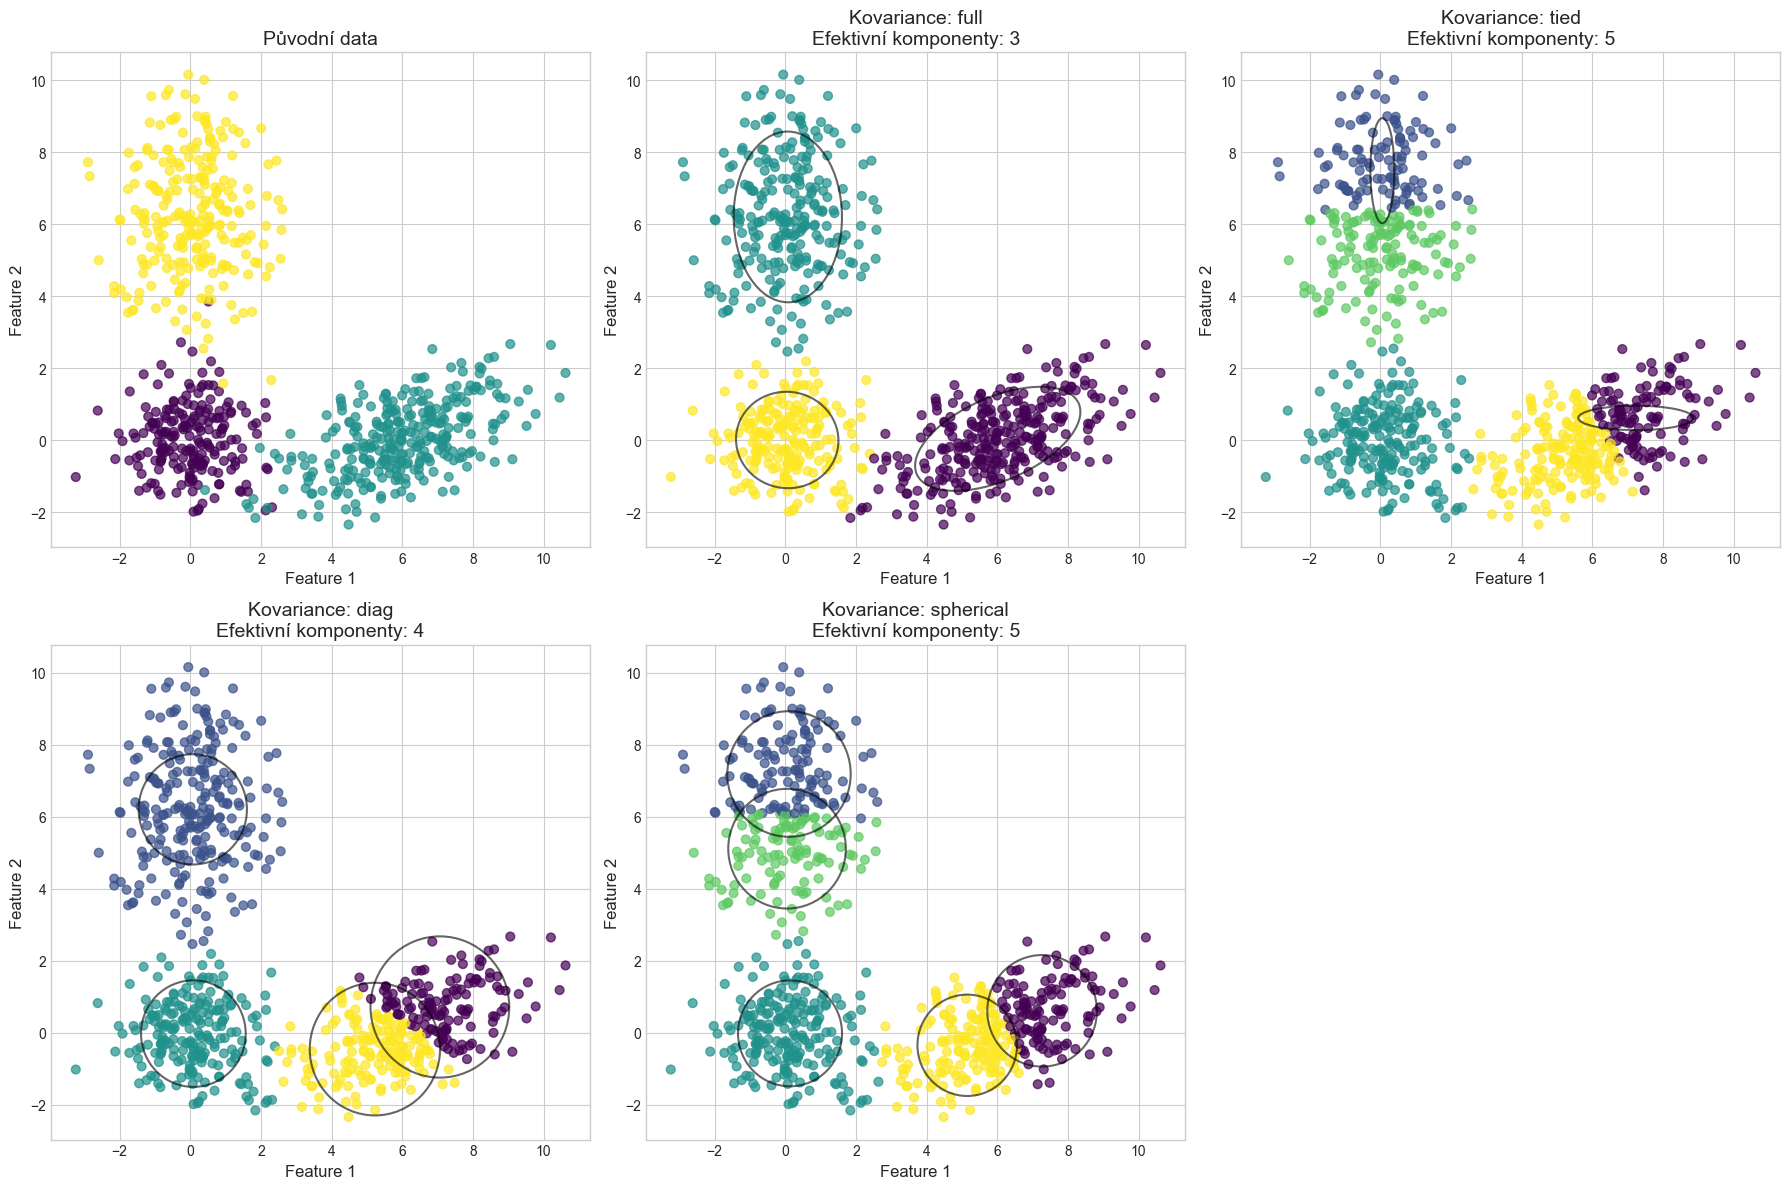

Metriky pro různé typy kovariancí:
  Kovarianční typ  Efektivní komponenty  Silhouette skóre    ARI  Lower bound
0            full                     3             0.622  0.951    -1837.570
1            tied                     5             0.460  0.636    -1930.515
2            diag                     4             0.526  0.771    -1887.611
3       spherical                     5             0.448  0.628    -1927.807


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import BayesianGaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
import pandas as pd

# Vytvoření dat se složitějšími shluky
np.random.seed(42)
X_complex = np.vstack([
    np.random.multivariate_normal([0, 0], [[1, 0], [0, 1]], 200),  # Kulatý shluk
    np.random.multivariate_normal([6, 0], [[3, 1], [1, 1]], 300),  # Eliptický shluk
    np.random.multivariate_normal([0, 6], [[1, 0], [0, 3]], 250)   # Eliptický shluk ve směru y
])
y_complex = np.hstack([np.zeros(200), np.ones(300), 2*np.ones(250)])

# Typy kovariančních matic
cov_types = ['full', 'tied', 'diag', 'spherical']
models = []
labels = []

for cov_type in cov_types:
    vbgmm = BayesianGaussianMixture(
        n_components=5,
        covariance_type=cov_type,
        weight_concentration_prior=0.1,
        random_state=42,
        max_iter=200
    )
    vbgmm.fit(X_complex)
    models.append(vbgmm)
    labels.append(vbgmm.predict(X_complex))

# Vizualizace výsledků
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Původní data
axes[0].scatter(X_complex[:, 0], X_complex[:, 1], c=y_complex, cmap='viridis', alpha=0.7, s=40)
axes[0].set_title('Původní data', fontsize=14)
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].grid(True)

# Výsledky pro různé typy kovariancí
for i, (cov_type, model, label) in enumerate(zip(cov_types, models, labels)):
    axes[i+1].scatter(X_complex[:, 0], X_complex[:, 1], c=label, cmap='viridis', alpha=0.7, s=40)
    
    # Vykreslení elips pro komponenty s váhou > 1%
    for j, (mean, covar, weight) in enumerate(zip(model.means_, model.covariances_, model.weights_)):
        if weight > 0.01:
            # Pro různé typy kovariancí musíme s nimi zacházet jinak
            if cov_type == 'full' or cov_type == 'tied':
                # Pro full a tied covariance, která by měla být 2D matice
                if covar.ndim == 1:
                    covar = np.diag(covar)  # Převeďte na 2D matici, pokud je to 1D
                
                v, w = np.linalg.eigh(covar)
                v = 2. * np.sqrt(2.) * np.sqrt(v)
                u = w[0] / np.linalg.norm(w[0])
                angle = np.arctan2(u[1], u[0])
                angle = 180. * angle / np.pi
                ell = plt.matplotlib.patches.Ellipse(
                    mean, v[0], v[1], angle=180. + angle, 
                    edgecolor='black', lw=1.5, facecolor='none', alpha=0.6
                )
            elif cov_type == 'diag':
                # Diagonální kovarianční matice (pouze variance)
                v = 2. * np.sqrt(2.) * np.sqrt(covar)
                # Fix: Correct the way the Ellipse is created, passing only width and height
                ell = plt.matplotlib.patches.Ellipse(
                    mean, v[0], v[0], angle=0,  # Same value for width and height (using first value of v for both)
                    edgecolor='black', lw=1.5, facecolor='none', alpha=0.6
                )
            else:  # spherical
                # Sférická kovarianční matice (zobrazí to jako stejné hodnoty pro oba směry)
                # Vytvoříme 2D kovarianci ze skalaru
                covar_spherical = np.array([[covar, 0], [0, covar]])
                v, w = np.linalg.eigh(covar_spherical)
                v = 2. * np.sqrt(2.) * np.sqrt(v)
                u = w[0] / np.linalg.norm(w[0])
                angle = np.arctan2(u[1], u[0])
                angle = 180. * angle / np.pi
                ell = plt.matplotlib.patches.Ellipse(
                    mean, v[0], v[1], angle=180. + angle, 
                    edgecolor='black', lw=1.5, facecolor='none', alpha=0.6
                )
            
            ell.set_clip_box(axes[i+1].bbox)
            axes[i+1].add_artist(ell)
    
    n_eff = np.sum(model.weights_ > 0.01)
    axes[i+1].set_title(f'Kovariance: {cov_type}\nEfektivní komponenty: {n_eff}', fontsize=14)
    axes[i+1].set_xlabel('Feature 1', fontsize=12)
    axes[i+1].set_ylabel('Feature 2', fontsize=12)
    axes[i+1].grid(True)

# Odstranění prázdné osy
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# Tabulka s metrikami pro jednotlivé typy kovariancí
metrics = []
for i, (cov_type, model, label) in enumerate(zip(cov_types, models, labels)):
    if len(np.unique(label)) > 1:
        silhouette = silhouette_score(X_complex, label)
    else:
        silhouette = 0
    
    ari = adjusted_rand_score(y_complex, label)
    n_eff = np.sum(model.weights_ > 0.01)
    
    metrics.append({
        'Kovarianční typ': cov_type,
        'Efektivní komponenty': n_eff,
        'Silhouette skóre': silhouette,
        'ARI': ari,
        'Lower bound': model.lower_bound_
    })

metrics_df = pd.DataFrame(metrics)
print("Metriky pro různé typy kovariancí:")
print(metrics_df.round(3))

## 5. Aplikace VBGMM na reálná data - Iris dataset

In [11]:
# Načtení Iris datasetu
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names = iris.feature_names

# Standardizace dat
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# Aplikace VBGMM
vbgmm_iris = BayesianGaussianMixture(
    n_components=10,  # Začínáme s více komponentami než je tříd
    weight_concentration_prior=0.1, 
    covariance_type='full',
    random_state=42,
    max_iter=200
)

vbgmm_iris.fit(X_iris_scaled)
iris_labels = vbgmm_iris.predict(X_iris_scaled)

# Počet efektivních komponent
n_eff_components = np.sum(vbgmm_iris.weights_ > 0.01)
print(f"Počet efektivních komponent: {n_eff_components}")
print(f"Skutečný počet tříd v Iris datasetu: 3")

# Váhy komponent
print("\nVáhy komponent:")
for i, weight in enumerate(vbgmm_iris.weights_):
    if weight > 0.01:
        print(f"Komponenta {i+1}: {weight:.4f}")

# Metriky výkonu
ari_iris = adjusted_rand_score(y_iris, iris_labels)
silhouette_iris = silhouette_score(X_iris_scaled, iris_labels)

print(f"\nAdjusted Rand Index: {ari_iris:.3f}")
print(f"Silhouette skóre: {silhouette_iris:.3f}")

Počet efektivních komponent: 5
Skutečný počet tříd v Iris datasetu: 3

Váhy komponent:
Komponenta 1: 0.1082
Komponenta 2: 0.3350
Komponenta 3: 0.0129
Komponenta 4: 0.4214
Komponenta 6: 0.1041

Adjusted Rand Index: 0.534
Silhouette skóre: 0.219


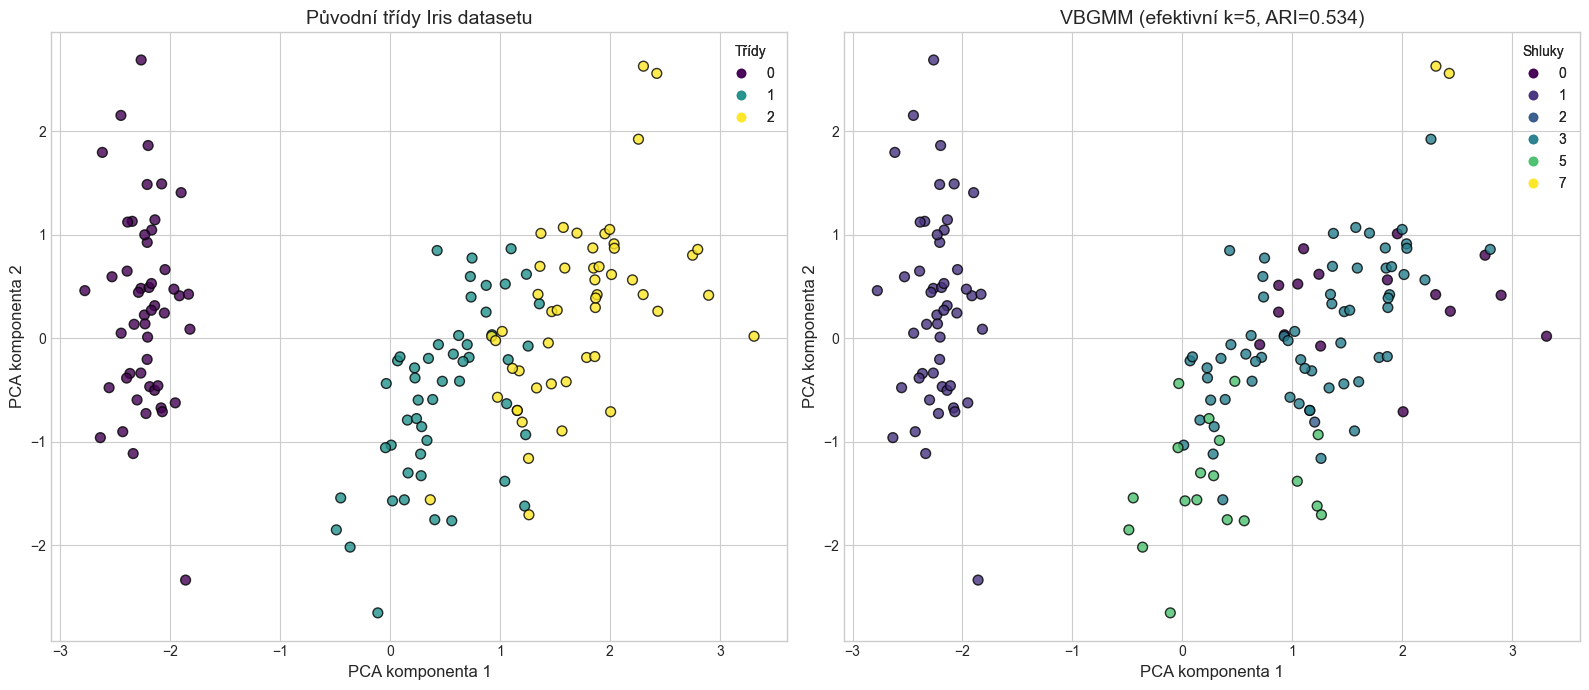

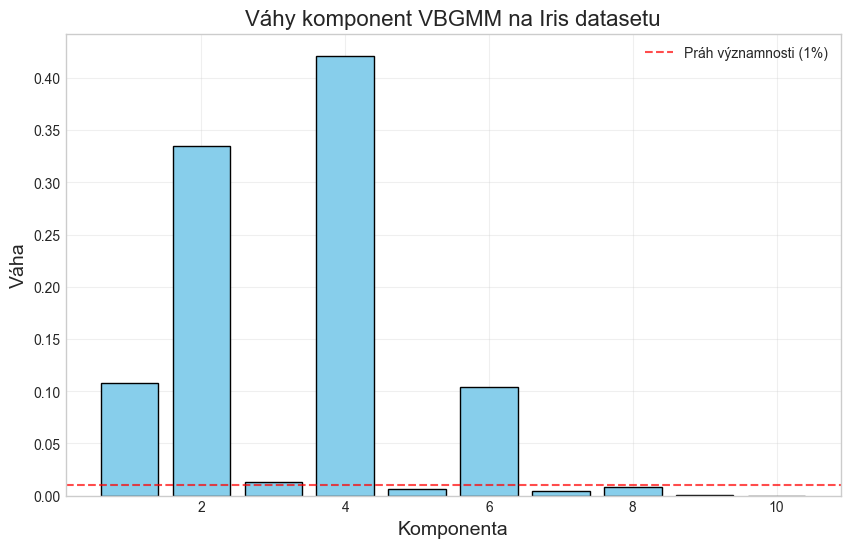

In [12]:
# Vizualizace výsledků pomocí PCA
pca = PCA(n_components=2)
X_iris_pca = pca.fit_transform(X_iris_scaled)

# Vykreslení výsledků
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Původní třídy
scatter1 = axes[0].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=y_iris, 
                         cmap='viridis', alpha=0.8, s=50, edgecolor='k')
axes[0].set_title('Původní třídy Iris datasetu', fontsize=14)
axes[0].set_xlabel('PCA komponenta 1', fontsize=12)
axes[0].set_ylabel('PCA komponenta 2', fontsize=12)
axes[0].grid(True)
legend1 = axes[0].legend(*scatter1.legend_elements(), 
                       loc="upper right", title="Třídy")
axes[0].add_artist(legend1)

# VBGMM shluky
scatter2 = axes[1].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=iris_labels, 
                         cmap='viridis', alpha=0.8, s=50, edgecolor='k')
axes[1].set_title(f'VBGMM (efektivní k={n_eff_components}, ARI={ari_iris:.3f})', fontsize=14)
axes[1].set_xlabel('PCA komponenta 1', fontsize=12)
axes[1].set_ylabel('PCA komponenta 2', fontsize=12)
axes[1].grid(True)
legend2 = axes[1].legend(*scatter2.legend_elements(), 
                       loc="upper right", title="Shluky")
axes[1].add_artist(legend2)

plt.tight_layout()
plt.show()

# Vizualizace vah komponent
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(vbgmm_iris.weights_) + 1), vbgmm_iris.weights_, 
       color='skyblue', edgecolor='black')
plt.axhline(y=0.01, linestyle='--', color='red', alpha=0.7, 
           label='Práh významnosti (1%)')
plt.xlabel('Komponenta', fontsize=14)
plt.ylabel('Váha', fontsize=14)
plt.title('Váhy komponent VBGMM na Iris datasetu', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. VBGMM pro segmentaci obrazu

Ukážeme použití VBGMM pro segmentaci obrazu - konkrétně pro zredukování počtu barev.

In [13]:
# try:
#     # Pokus o načtení ukázkového obrazu ze scikit-learn
#     from sklearn.datasets import load_sample_image
#     img = load_sample_image('china.jpg')
# except:
#     # Alternativně vytvoříme náhodný obraz
#     np.random.seed(42)
#     img = np.random.randint(0, 255, (300, 300, 3), dtype=np.uint8)

# # Zobrazení původního obrazu
# plt.figure(figsize=(8, 8))
# plt.imshow(img)
# plt.title('Původní obraz', fontsize=14)
# plt.axis('off')
# plt.show()

# # Příprava dat pro VBGMM
# h, w, d = img.shape
# image_array = np.reshape(img, (h * w, d))

# # Pro zrychlení použijeme náhodný vzorek pixelů
# n_samples = 10000  # Počet pixelů pro trénování modelu
# np.random.seed(42)
# indices = np.random.choice(image_array.shape[0], n_samples, replace=False)
# sample = image_array[indices]

# # Normalizace dat do rozsahu [0,1]
# sample_normalized = sample / 255.0

# # Aplikace VBGMM pro segmentaci barev
# print("Trénování VBGMM modelu pro segmentaci obrazu...")
# vbgmm_image = BayesianGaussianMixture(
#     n_components=15,  # Začínáme s 15 potenciálními barvami
#     weight_concentration_prior=0.7, 
#     max_iter=100,
#     random_state=42
# )

# vbgmm_image.fit(sample_normalized)

# # Počet efektivních barevných komponent
# n_eff_colors = np.sum(vbgmm_image.weights_ > 0.01)
# print(f"Efektivní počet barevných komponent: {n_eff_colors}")
# print("Váhy nejvýznamnějších komponent:")
# sorted_indices = np.argsort(vbgmm_image.weights_)[::-1]
# for i, idx in enumerate(sorted_indices[:5]):
#     print(f"  {i+1}. barva: {vbgmm_image.weights_[idx]:.4f}")

# # Aplikace modelu na celý obraz
# print("Segmentace celého obrazu...")
# # Normalizace všech pixelů
# image_normalized = image_array / 255.0

# # Pro větší obrazy zpracováváme po částech, aby se vešly do paměti
# batch_size = 10000
# n_batches = int(np.ceil(image_normalized.shape[0] / batch_size))
# predicted_labels = np.zeros(image_normalized.shape[0], dtype=int)

# for i in range(n_batches):
#     start_idx = i * batch_size
#     end_idx = min((i + 1) * batch_size, image_normalized.shape[0])
#     batch = image_normalized[start_idx:end_idx]
#     predicted_labels[start_idx:end_idx] = vbgmm_image.predict(batch)

# # Vytvoření segmentovaného obrazu
# segmented_image = np.zeros_like(image_array, dtype=np.float32)
# for i in range(vbgmm_image.n_components):
#     segmented_image[predicted_labels == i] = vbgmm_image.means_[i] * 255

# segmented_image = segmented_image.reshape(h, w, d).astype(np.uint8)

# # Zobrazení výsledků
# fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# axes[0].imshow(img)
# axes[0].set_title('Původní obraz', fontsize=14)
# axes[0].axis('off')

# axes[1].imshow(segmented_image)
# axes[1].set_title(f'VBGMM segmentace ({n_eff_colors} efektivních barev)', fontsize=14)
# axes[1].axis('off')

# plt.tight_layout()
# plt.show()

# # Zobrazení barevné palety
# plt.figure(figsize=(12, 3))
# n_display = min(10, n_eff_colors)
# for i in range(n_display):
#     idx = sorted_indices[i]
#     color = vbgmm_image.means_[idx]
#     plt.subplot(1, n_display, i+1)
#     plt.axhspan(0, 1, color=color)
#     plt.title(f"{vbgmm_image.weights_[idx]:.3f}", fontsize=10)
#     plt.axis('off')
# plt.suptitle('Dominantní barvy (s vahami)', fontsize=14)
# plt.tight_layout()
# plt.subplots_adjust(top=0.85)
# plt.show()

```
ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
```

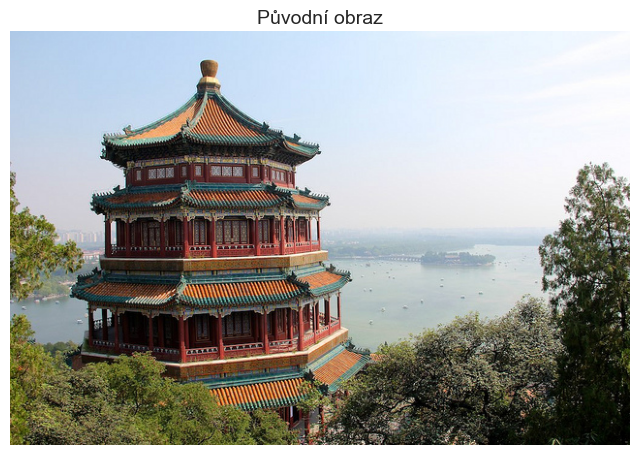

Trénování VBGMM modelu pro segmentaci obrazu...
Efektivní počet barevných komponent: 15
Váhy nejvýznamnějších komponent:
  1. barva: 0.2029
  2. barva: 0.1169
  3. barva: 0.0883
  4. barva: 0.0753
  5. barva: 0.0691
Segmentace celého obrazu...


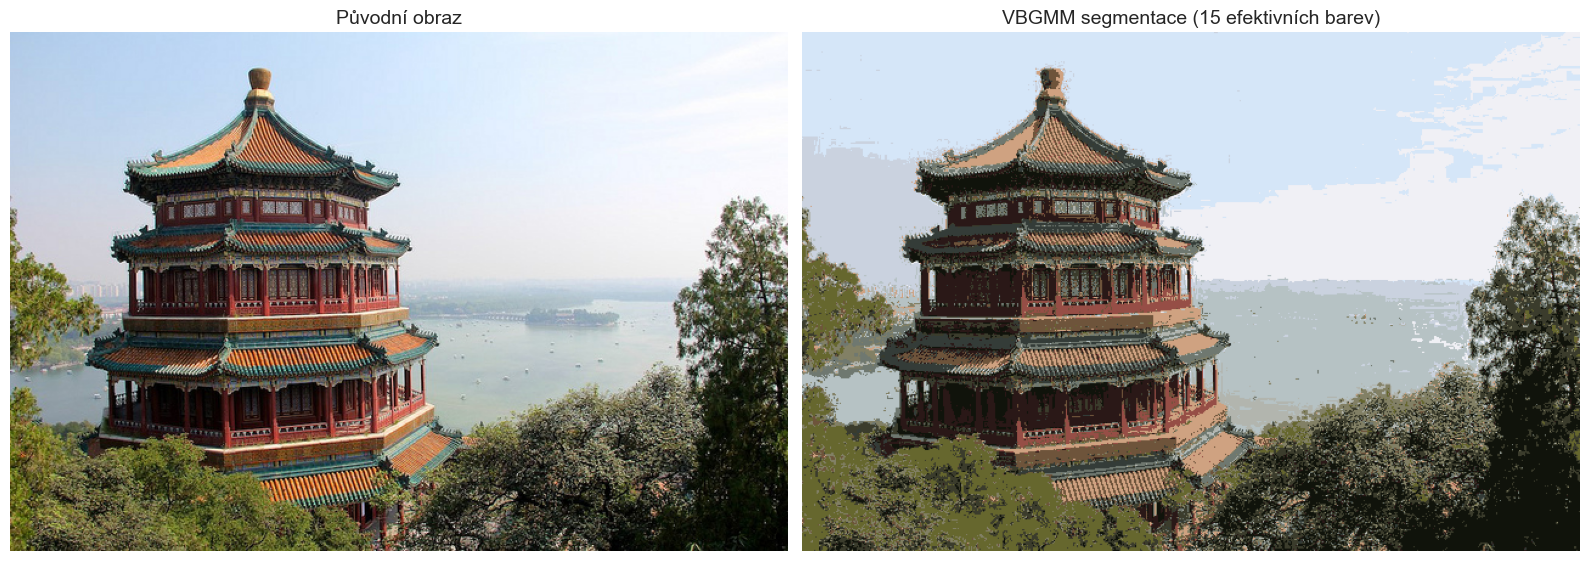

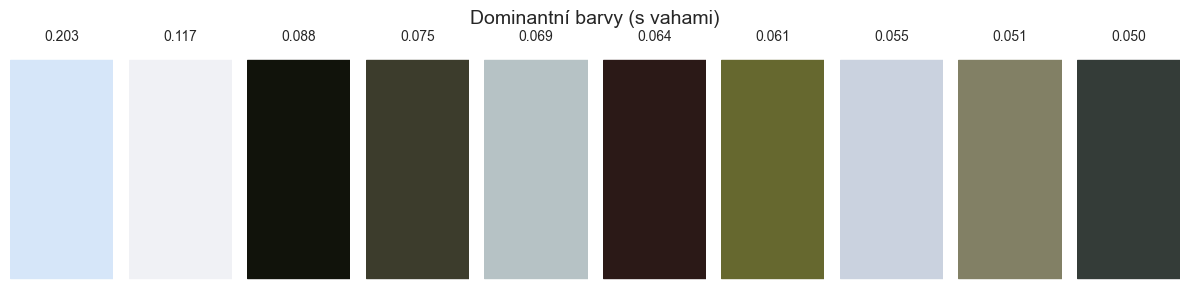

In [14]:
import warnings
from sklearn.mixture import BayesianGaussianMixture
import numpy as np
import matplotlib.pyplot as plt

# Suppress ConvergenceWarning
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.mixture._base")

try:
    # Pokus o načtení ukázkového obrazu ze scikit-learn
    from sklearn.datasets import load_sample_image
    img = load_sample_image('china.jpg')
except:
    # Alternativně vytvoříme náhodný obraz
    np.random.seed(42)
    img = np.random.randint(0, 255, (300, 300, 3), dtype=np.uint8)

# Zobrazení původního obrazu
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title('Původní obraz', fontsize=14)
plt.axis('off')
plt.show()

# Příprava dat pro VBGMM
h, w, d = img.shape
image_array = np.reshape(img, (h * w, d))

# Pro zrychlení použijeme náhodný vzorek pixelů
n_samples = 10000  # Počet pixelů pro trénování modelu
np.random.seed(42)
indices = np.random.choice(image_array.shape[0], n_samples, replace=False)
sample = image_array[indices]

# Normalizace dat do rozsahu [0,1]
sample_normalized = sample / 255.0

# Aplikace VBGMM pro segmentaci barev
print("Trénování VBGMM modelu pro segmentaci obrazu...")
vbgmm_image = BayesianGaussianMixture(
    n_components=15,  # Začínáme s 15 potenciálními barvami
    weight_concentration_prior=0.7, 
    max_iter=100,
    random_state=42
)

vbgmm_image.fit(sample_normalized)

# Počet efektivních barevných komponent
n_eff_colors = np.sum(vbgmm_image.weights_ > 0.01)
print(f"Efektivní počet barevných komponent: {n_eff_colors}")
print("Váhy nejvýznamnějších komponent:")
sorted_indices = np.argsort(vbgmm_image.weights_)[::-1]
for i, idx in enumerate(sorted_indices[:5]):
    print(f"  {i+1}. barva: {vbgmm_image.weights_[idx]:.4f}")

# Aplikace modelu na celý obraz
print("Segmentace celého obrazu...")
# Normalizace všech pixelů
image_normalized = image_array / 255.0

# Pro větší obrazy zpracováváme po částech, aby se vešly do paměti
batch_size = 10000
n_batches = int(np.ceil(image_normalized.shape[0] / batch_size))
predicted_labels = np.zeros(image_normalized.shape[0], dtype=int)

for i in range(n_batches):
    start_idx = i * batch_size
    end_idx = min((i + 1) * batch_size, image_normalized.shape[0])
    batch = image_normalized[start_idx:end_idx]
    predicted_labels[start_idx:end_idx] = vbgmm_image.predict(batch)

# Vytvoření segmentovaného obrazu
segmented_image = np.zeros_like(image_array, dtype=np.float32)
for i in range(vbgmm_image.n_components):
    segmented_image[predicted_labels == i] = vbgmm_image.means_[i] * 255

segmented_image = segmented_image.reshape(h, w, d).astype(np.uint8)

# Zobrazení výsledků
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img)
axes[0].set_title('Původní obraz', fontsize=14)
axes[0].axis('off')

axes[1].imshow(segmented_image)
axes[1].set_title(f'VBGMM segmentace ({n_eff_colors} efektivních barev)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Zobrazení barevné palety
plt.figure(figsize=(12, 3))
n_display = min(10, n_eff_colors)
for i in range(n_display):
    idx = sorted_indices[i]
    color = vbgmm_image.means_[idx]
    plt.subplot(1, n_display, i+1)
    plt.axhspan(0, 1, color=color)
    plt.title(f"{vbgmm_image.weights_[idx]:.3f}", fontsize=10)
    plt.axis('off')
plt.suptitle('Dominantní barvy (s vahami)', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

## 7. Shrnutí algoritmu VBGMM

### Výhody VBGMM:

1. **Automatické určení počtu shluků** - Začínáme s větším počtem komponent, než očekáváme, a algoritmus sám určí efektivní počet
2. **Bayesovská regularizace** - Pomáhá předcházet přefitování a nestabilitě, které mohou vzniknout u standardního GMM
3. **Flexibilní modelování** - Různé typy kovariančních matic umožňují modelovat shluky různých tvarů a velikostí
4. **Pravděpodobnostní přiřazení** - Poskytuje pravděpodobnosti příslušnosti ke shlukům namísto pevných přiřazení
5. **Ladění komplexity** - Parametr `weight_concentration_prior` umožňuje ovlivnit počet efektivních shluků

### Nevýhody VBGMM:

1. **Výpočetní náročnost** - Obvykle pomalejší než standardní GMM nebo k-means
2. **Složitější interpretace** - Pravděpodobnostní model může být hůře interpretovatelný než jednoduché metody jako k-means
3. **Citlivost na inicializaci** - Výsledky mohou záviset na náhodné inicializaci
4. **Předpoklady o datech** - Stále předpokládá, že data lze modelovat jako směs Gaussovských rozdělení
5. **Potřeba ladění hyperparametrů** - Správná volba `weight_concentration_prior` a dalších parametrů může vyžadovat experimentování

### Klíčové parametry VBGMM:

- **n_components** - Maximální počet komponent (nastavuje se vyšší než očekávaný počet shluků)
- **weight_concentration_prior** - Určuje apriorní koncentraci vah (nižší hodnoty → méně shluků)
- **covariance_type** - Typ kovariančních matic ('full', 'tied', 'diag', 'spherical')
- **mean_precision_prior** - Ovlivňuje apriorní přesnost středů shluků
- **degrees_of_freedom_prior** - Apriorní stupně volnosti (vyšší → silnější regularizace kovariance)
- **weight_concentration_prior_type** - Typ apriorní koncentrace ('dirichlet_process' nebo 'dirichlet_distribution')

### Použití VBGMM v praxi:

- Pro automatické určení počtu shluků v datech
- Pro modelování dat se složitými, překrývajícími se strukturami
- Pro pravděpodobnostní přiřazení do shluků, kde je nejistota důležitá
- V generativních modelech pro simulaci nových dat z naučeného rozdělení